In [87]:
import numpy as np
import pandas as pd

# Import plotting tools
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap
from matplotlib.gridspec import GridSpec

# Load data

In [2]:
df = pd.read_parquet('./meta_data/df.parquet')

In [6]:
df.columns

Index(['animal_id', 'session_id', 'scan_id', 'unit_id', 'depth', 'x', 'y',
       'oracle_chirp', 'oracle_bar', 'dsi', 'pref_dir', 'p_dsi', 'DS_bool',
       'osi', 'pref_ori', 'p_osi', 'OS_bool', 'RTi', 'OOi', 'TRACE_0',
       'TRACE_1', 'mask_artifacts', 'mask_clustered', 'response_type_ID'],
      dtype='str')

In [54]:
resp_chirp = np.load('./data/resp_chirp_71021.npy')
resp_bar = np.load('./data/resp_bar_71021.npy')

# Plot cluster means
(for dendrogram see notebook `clustering.ipynb`)

In [55]:
# Plotting properties
n_clusters = int(np.nanmax(np.unique(df['response_type_ID'].values)))+1
n_bins_hist = 10
resp_cluster_mean = []
resp_cluster_sd = []

depths = df['depth'].values
DSi = df['dsi'].values
OSi = df['osi'].values

# Colormap
cmap = ListedColormap(sns.husl_palette(n_clusters).as_hex())

# Cluster names
cluster_names = {i: str(i+1) for i in range(50)}

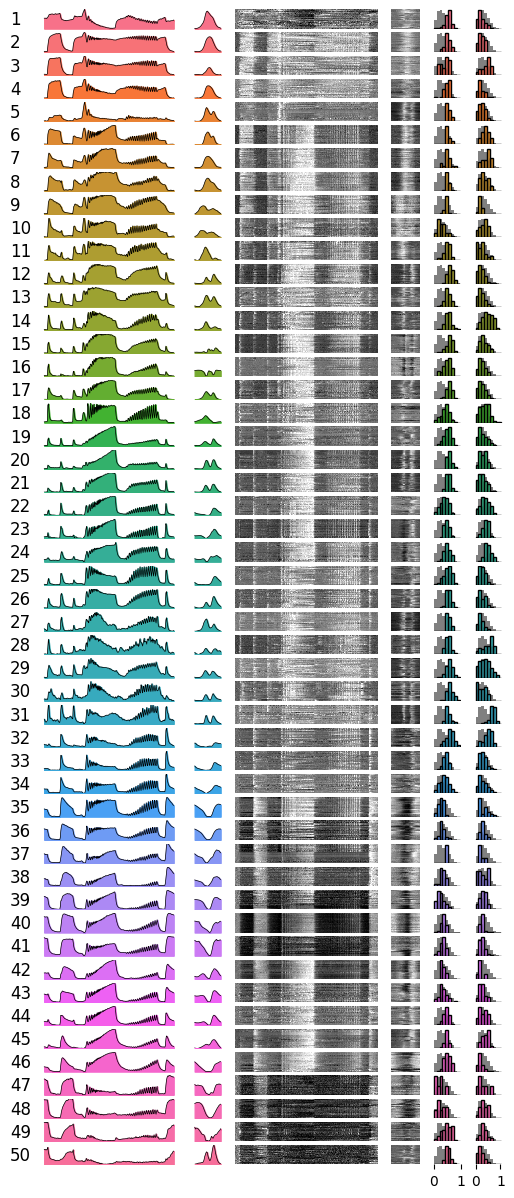

In [58]:
fig, axs = plt.subplots(n_clusters,6, figsize=(6,15), gridspec_kw = {'width_ratios':[1, .2, 1, .2, .2, .2]})

# Loop over cluster
for i in range(50):

    # Get ROIs in specific cluster
    df_cluster = df[df['response_type_ID'] == i]
    mask = df['response_type_ID'] == i
    cluster_indices = np.where(mask.values)[0]
    n_neurons_cluster = len(cluster_indices)
    assert len(cluster_indices) == df_cluster.shape[0], "Mismatch: number of responses and entries in meta data don't match!"

    # Get responses
    resp_imshow_chirp = resp_chirp[cluster_indices]
    resp_imshow_bar = np.mean(np.reshape(resp_bar[cluster_indices], [n_neurons_cluster, 8, 32]), axis=1)

    # Get mean cluster response
    resp_plot_chirp = np.mean(resp_imshow_chirp, axis=0)
    resp_plot_bar = np.mean(resp_imshow_bar, axis=0)

    ylim_max_resp = np.max([np.max(resp_plot_chirp), np.max(resp_plot_bar)])

    # Cluster response chirp
    ax=axs[i,0]
    ax.plot(resp_plot_chirp, color='k', lw=.5)
    ax.fill_between(x=np.linspace(0,resp_plot_chirp.shape[0]-1,resp_plot_chirp.shape[0]), 
                    y1=np.ones(resp_plot_chirp.shape)*np.min(resp_plot_chirp), 
                    y2=resp_plot_chirp,
                    color=cmap.colors[i])
    ax.set_ylim([np.min(resp_plot_chirp), ylim_max_resp])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylabel(cluster_names[i], 
                  rotation=0, 
                  fontsize=12, 
                  labelpad=20,#200, 
                  loc='bottom')
    ax.patch.set_alpha(0)

    # Cluster response bar
    ax=axs[i,1]
    ax.plot(resp_plot_bar, color='k', lw=.5)
    ax.fill_between(x=np.linspace(0,resp_plot_bar.shape[0]-1,resp_plot_bar.shape[0]), 
                    y1=np.ones(resp_plot_bar.shape)*np.min(resp_plot_bar), 
                    y2=resp_plot_bar,
                    color=cmap.colors[i])
    ax.set_ylim([np.min(resp_plot_bar), ylim_max_resp])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.patch.set_alpha(0)

    # Heatmap responses chirp
    ax=axs[i,2]
    ax.imshow(resp_imshow_chirp, cmap='gray', aspect='auto', interpolation='none')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.patch.set_alpha(0)

    # Heatmap responses bar
    ax=axs[i,3]
    ax.imshow(resp_imshow_bar, cmap='gray', aspect='auto', interpolation='none')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.patch.set_alpha(0)
    
    # Direction selectivity
    ax=axs[i,4]
    idx_DS = np.where((df_cluster['DS_bool']==1).values)[0] # select only direction selective ROIs
    DSi_cluster = df_cluster['dsi'].values
    DSi_cluster_DS_only = DSi_cluster[idx_DS]
    ax.hist(DSi, color='gray', bins=np.linspace(np.min(DSi), np.max(DSi), n_bins_hist), density=True);
    ax_cluster = ax.twinx() # separate axis for all ROIs and cluster specific ROIs
    ax_cluster.hist(DSi_cluster_DS_only, color=cmap.colors[i], bins=np.linspace(np.min(DSi), np.max(DSi), n_bins_hist), density=True)
    ax_cluster.hist(DSi_cluster_DS_only, facecolor='none', edgecolor='k', bins=np.linspace(np.min(DSi), np.max(DSi), n_bins_hist), density=True)
    ax_cluster.set_xticks([])
    ax_cluster.set_yticks([])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.patch.set_alpha(0)
    
    # Orientation selectivity
    ax=axs[i,5]
    idx_OS = np.where((df_cluster['OS_bool']==1).values)[0] # select only orientation selective ROIs
    OSi_cluster = df_cluster['osi'].values
    OSi_cluster_cluster_OS_only = OSi_cluster[idx_DS]
    ax.hist(OSi, color='gray', bins=np.linspace(np.min(OSi), np.max(OSi), n_bins_hist), density=True);
    ax_cluster = ax.twinx() # separate axis for all ROIs (gray) and cluster specific ROIs (colored)
    ax_cluster.hist(OSi_cluster_cluster_OS_only, color=cmap.colors[i], bins=np.linspace(np.min(OSi), np.max(OSi), n_bins_hist), density=True)
    ax_cluster.hist(OSi_cluster_cluster_OS_only, facecolor='none', edgecolor='k', bins=np.linspace(np.min(OSi), np.max(OSi), n_bins_hist), density=True)
    ax_cluster.set_xticks([])
    ax_cluster.set_yticks([])    
    ax.set_xticks([])
    ax.set_yticks([])
    ax.patch.set_alpha(0)
    
axs[-1,4].set_xticks([0,1])
axs[-1,5].set_xticks([0,1])
        
sns.despine(bottom=True, left=True)

fig.patch.set_facecolor('white')
fig.savefig('./plots/Fig2a.png', dpi=600, bbox_inches='tight')
fig.savefig('./plots/Fig2a.svg', bbox_inches='tight')

# Example cluster

In [92]:
img_chirp_stim = plt.imread(f'./schematics/stimulus_schematic_chirp.png')
img_bar_stim = plt.imread(f'./schematics/stimulus_schematic_bar.png')

To plot location of the ROI within scan field, check which scan has most ROIs per cluster and save this as `cluster_best_scan`. Because the scan coordinates are not registered across scans, pooling across scans would not be valid.

In [91]:
valid_scan_keys = df[['animal_id', 'session_id', 'scan_id']].drop_duplicates() \
    .apply(lambda row: f"{row['animal_id']}-{row['session_id']}-{row['scan_id']}", axis=1) \
    .tolist()

cluster_best_scan = {}

for cluster_idx in range(50):
    scan_roi_counts = {}
    
    for valid_scan_key in valid_scan_keys:
        parts = valid_scan_key.split('-')
        valid_animal_id = int(parts[0])
        valid_session_id = int(parts[1])
        valid_scan_id = int(parts[2])
    
        df_scan = df[
            (df['animal_id'] == valid_animal_id) &
            (df['session_id'] == valid_session_id) &
            (df['scan_id'] == valid_scan_id)
        ]
        
        # Count ROIs for this cluster in this scan
        cluster_data = df_scan[df_scan['response_type_ID'] == cluster_idx]
        n_rois = cluster_data.shape[0]
        scan_roi_counts[valid_scan_key] = n_rois
    
    # Find scan with most ROIs for this cluster
    if scan_roi_counts and max(scan_roi_counts.values()) > 0:  # Only if cluster exists
        best_scan = max(scan_roi_counts, key=scan_roi_counts.get)
        cluster_best_scan[cluster_idx] = best_scan
        print(f"Cluster {cluster_idx}: {best_scan} ({scan_roi_counts[best_scan]} ROIs)")
    else:
        print(f"Cluster {cluster_idx}: No ROIs found")

Cluster 0: 28188-12-11 (100 ROIs)
Cluster 1: 28712-2-5 (198 ROIs)
Cluster 2: 28712-2-4 (118 ROIs)
Cluster 3: 28712-2-5 (124 ROIs)
Cluster 4: 28188-10-8 (211 ROIs)
Cluster 5: 28188-12-14 (210 ROIs)
Cluster 6: 29163-1-12 (442 ROIs)
Cluster 7: 29163-1-12 (404 ROIs)
Cluster 8: 28188-13-11 (281 ROIs)
Cluster 9: 28188-13-9 (282 ROIs)
Cluster 10: 28188-13-10 (514 ROIs)
Cluster 11: 28188-10-15 (374 ROIs)
Cluster 12: 28188-13-10 (398 ROIs)
Cluster 13: 29163-1-11 (924 ROIs)
Cluster 14: 28188-12-11 (210 ROIs)
Cluster 15: 28188-12-13 (129 ROIs)
Cluster 16: 28188-10-8 (306 ROIs)
Cluster 17: 28712-2-4 (367 ROIs)
Cluster 18: 28712-2-5 (358 ROIs)
Cluster 19: 28188-12-12 (223 ROIs)
Cluster 20: 28188-12-13 (253 ROIs)
Cluster 21: 28712-2-4 (477 ROIs)
Cluster 22: 28712-2-4 (501 ROIs)
Cluster 23: 28188-12-13 (121 ROIs)
Cluster 24: 29163-1-11 (312 ROIs)
Cluster 25: 29163-2-8 (255 ROIs)
Cluster 26: 28712-2-4 (559 ROIs)
Cluster 27: 29163-1-11 (501 ROIs)
Cluster 28: 28188-12-11 (397 ROIs)
Cluster 29: 28712-3-8

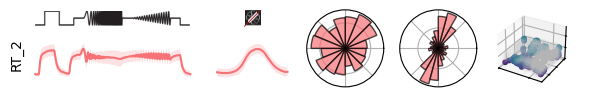

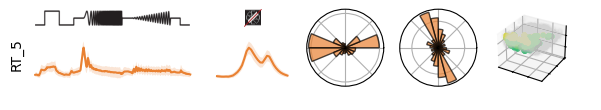

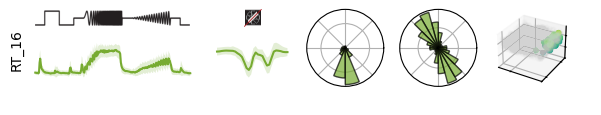

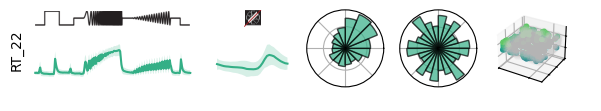

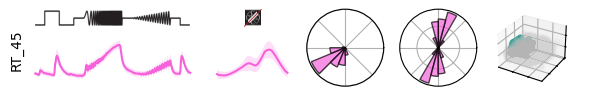

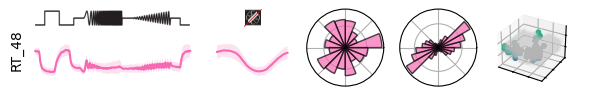

In [98]:
selected_clusters = np.array([2,
                              5,
                              16,
                              22,
                              45,
                              48])-1

for cluster_idx in selected_clusters:

    cluster_data = df[df['response_type_ID'] == cluster_idx]
    mask = df['response_type_ID'] == cluster_idx
    cluster_indices = np.where(mask.values)[0]
    n_neurons_cluster = len(cluster_indices)
    assert len(cluster_indices) == cluster_data.shape[0], "Mismatch: number of responses and entries in meta data don't match!"

    # Get chirp and moving bar responses
    resp_imshow_chirp = resp_chirp[cluster_indices]
    resp_imshow_bar = np.mean(np.reshape(resp_bar[cluster_indices], [n_neurons_cluster, 8, 32]), axis=1)
    resp_plot_chirp = np.mean(resp_imshow_chirp, axis=0)
    resp_plot_bar = np.mean(resp_imshow_bar, axis=0)
    SD_plot_chirp = np.std(resp_imshow_chirp, axis=0)
    SD_plot_bar = np.std(resp_imshow_bar, axis=0)
    resp_min_chirp = (resp_plot_chirp-SD_plot_chirp).min()
    resp_min_bar = (resp_plot_bar-SD_plot_bar).min()
    resp_max_chirp = (resp_plot_chirp+SD_plot_chirp).max()
    resp_max_bar = (resp_plot_bar+SD_plot_bar).max()
    resp_range_chirp = resp_max_chirp - resp_min_chirp
    resp_range_bar = resp_max_bar - resp_min_bar
    y_axis_pad = np.mean(np.mean(SD_plot_chirp)+np.mean(SD_plot_bar))
    
    fig = plt.figure(figsize=(7, 1))

    # Create GridSpec with custom height ratios: height_ratios = [1, 3] means row 0 is 1 unit, row 1 is 3 units (so row 1 is 3x taller)
    gs = GridSpec(2, 6, figure=fig, height_ratios=[1, 3])
    
    ax1_ = fig.add_subplot(gs[0, 0:2])
    ax1 = fig.add_subplot(gs[1, 0:2])
    
    ax2_ = fig.add_subplot(gs[0, 2])
    ax2 = fig.add_subplot(gs[1, 2])
    
    ax3 = fig.add_subplot(gs[0:2, 3], projection='polar')
    ax4 = fig.add_subplot(gs[0:2, 4], projection='polar')
    ax5 = fig.add_subplot(gs[0:2, 5], projection='3d') 

    axs = [ax1, ax1_, ax2, ax2_, ax3, ax4, ax5]

    # Plot stimulus
    ax = ax1_
    ax.imshow(img_chirp_stim)
    ax.set_xlim([-100, 2300])
    ax.axes.set_axis_off()
    ax = ax2_
    ax.imshow(img_bar_stim)
    ax.axes.set_axis_off()
    
    # Response to chirp stimulus
    ax = ax1
    ax.plot(resp_plot_chirp, color=cmap.colors[cluster_idx])
    ax.fill_between(x=np.linspace(0,resp_plot_chirp.shape[0]-1,resp_plot_chirp.shape[0]), 
                    y1=resp_plot_chirp-SD_plot_chirp, 
                    y2=resp_plot_chirp+SD_plot_chirp,
                    facecolor=cmap.colors[cluster_idx],
                    edgecolor='none',
                    alpha=.2)
    ax.set_ylim(resp_min_chirp - y_axis_pad * resp_range_chirp, resp_max_chirp + y_axis_pad * resp_range_chirp)
    ax.axes.set_axis_off()
    
    # Response to moving bar stimulus
    ax = ax2
    ax.plot(resp_plot_bar, color=cmap.colors[cluster_idx])
    ax.fill_between(x=np.linspace(0,resp_plot_bar.shape[0]-1,resp_plot_bar.shape[0]), 
                    y1=resp_plot_bar-SD_plot_bar, 
                    y2=resp_plot_bar+SD_plot_bar,
                    facecolor=cmap.colors[cluster_idx],
                    edgecolor='none',
                    alpha=.2)
    ax.set_ylim(resp_min_bar - y_axis_pad * resp_range_bar, resp_max_bar + y_axis_pad * resp_range_bar)
    ax.axes.set_axis_off()
    
    # Preferred direction polar plot
    ax = ax3
    pref_dir_cluster = cluster_data['pref_dir']
    n_bins = 16
    bins_dir = np.linspace(-np.pi, np.pi, n_bins + 1)
    counts_dir, _ = np.histogram(pref_dir_cluster, bins=bins_dir)
    theta_dir = (bins_dir[:-1] + bins_dir[1:]) / 2  # Bin centers
    width_dir = 2 * np.pi / n_bins
    ax.bar(theta_dir, 
           counts_dir, 
           width=width_dir, 
           facecolor=cmap.colors[cluster_idx], 
           edgecolor='black', 
           alpha=0.7)
    ax.set_theta_zero_location('E')  # 0° at East (right)
    ax.set_theta_direction(1)  # Counter-clockwise
    ax.set_axisbelow(True)
    
    # Preferred orientation polar plot
    ax = ax4
    pref_ori_cluster = cluster_data['pref_ori']
    n_bins_ori = 12
    bins_ori = np.linspace(0, np.pi, n_bins_ori + 1)
    counts_ori, _ = np.histogram(pref_ori_cluster, bins=bins_ori)
    theta_ori = (bins_ori[:-1] + bins_ori[1:]) / 2
    # Mirror to make full circle for visualization
    theta_ori_full = np.concatenate([theta_ori, theta_ori + np.pi])
    counts_ori_full = np.concatenate([counts_ori, counts_ori])
    width_ori = np.pi / n_bins_ori
    ax.bar(theta_ori_full, 
           counts_ori_full, 
           width=width_ori, 
           facecolor=cmap.colors[cluster_idx], 
           edgecolor='black', 
           alpha=0.7)
    ax.set_theta_zero_location('E')
    ax.set_theta_direction(1)
    ax.set_axisbelow(True)
    
    # Location
    ax = ax5
    valid_scan_key = cluster_best_scan[cluster_idx] # Select the scan with the most ROIs for each cluster individually
    parts = valid_scan_key.split('-')
    animal_id = int(parts[0])
    session_id = int(parts[1])
    scan_id = int(parts[2])
    df_one_scan = df[(df['animal_id'] == animal_id) &
                     (df['session_id'] == session_id) &
                     (df['scan_id'] == scan_id)]
    cluster_data_xyz = df_one_scan[df_one_scan['response_type_ID'] == cluster_idx]
    other_data_xyz = df_one_scan[df_one_scan['response_type_ID'] != cluster_idx] 
    scatter_other = ax.scatter(
        other_data_xyz['x'].values, 
        other_data_xyz['y'].values, 
        other_data_xyz['depth'].values,
        c='lightgray',
        alpha=.03,
        s=10,
        rasterized=True,
    )
    scatter_cluster = ax.scatter(
        cluster_data_xyz['x'].values, 
        cluster_data_xyz['y'].values, 
        cluster_data_xyz['depth'].values,
        c=cluster_data_xyz['depth'],
        vmin=np.min(df['depth'].values), 
        vmax=np.max(df['depth'].values),
        cmap='viridis_r',
        alpha=1,
        s=10,
        rasterized=True,
    )
    ax.set_zlim([np.max(df['depth'].values), np.min(df['depth'].values)])
    
    for ax in axs:
        ax.set_xticklabels([])
        ax.set_yticklabels([])
    ax5.set_zticklabels([])
    
    fig.text(x=0.1, y=.3, s=f'RT_{cluster_idx+1}', rotation=90)    
    fig.patch.set_facecolor('white')

# Response properties across depths

In [ ]:
def normalize_rows(mat):
    row_min = mat.min(axis=1, keepdims=True)
    row_max = mat.max(axis=1, keepdims=True)
    denom = row_max - row_min
    denom[denom == 0] = 1

    return (mat - row_min) / denom

In [100]:
df.columns

Index(['animal_id', 'session_id', 'scan_id', 'unit_id', 'depth', 'x', 'y',
       'oracle_chirp', 'oracle_bar', 'dsi', 'pref_dir', 'p_dsi', 'DS_bool',
       'osi', 'pref_ori', 'p_osi', 'OS_bool', 'RTi', 'OOi', 'TRACE_0',
       'TRACE_1', 'mask_artifacts', 'mask_clustered', 'response_type_ID'],
      dtype='str')

In [101]:
RTi = df['RTi'].values
depth = df['depth'].values

(array([ 3441.,  8165., 12165., 14231.,  7034.,  9457.,  7910.,  5867.,
         2537.,   214.]),
 array([ 20.,  48.,  76., 104., 132., 160., 188., 216., 244., 272., 300.]),
 <BarContainer object of 10 artists>)

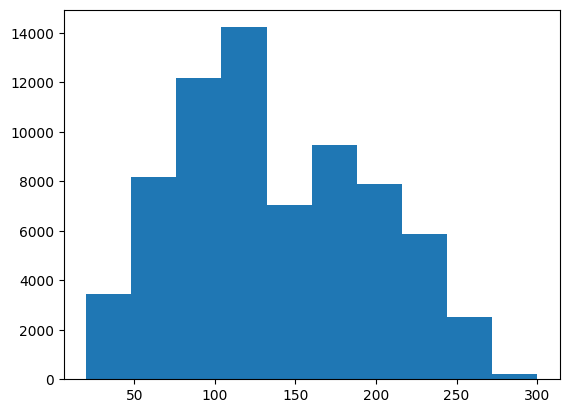

In [102]:
plt.hist(depths)

(array([3.8042e+04, 3.0727e+04, 1.6640e+03, 3.9000e+02, 1.2800e+02,
        4.6000e+01, 1.2000e+01, 6.0000e+00, 4.0000e+00, 2.0000e+00]),
 array([0.        , 0.65404412, 1.30808824, 1.96213237, 2.61617649,
        3.27022061, 3.92426473, 4.57830885, 5.23235297, 5.8863971 ,
        6.54044122]),
 <BarContainer object of 10 artists>)

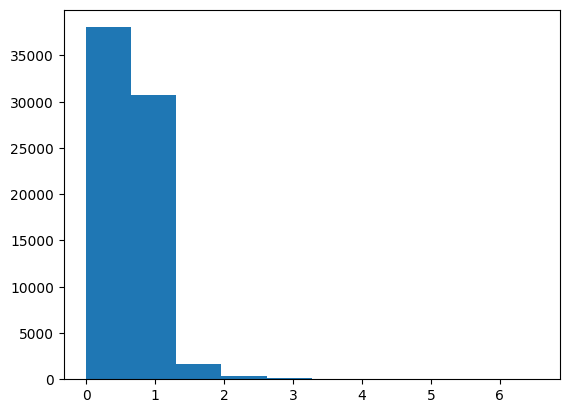

In [104]:
plt.hist(RTi)

In [ ]:
property_values
depths
n_depth_bins=10
n_property_bins=20
property_name='Property'
vmin=None
vmax=None
cmap='magma'

# Create 2D histogram
h, xedges, yedges = np.histogram2d(
    property_values, 
    depths, 
    bins=[n_property_bins, n_depth_bins]
)

# 2D TRACE embedding

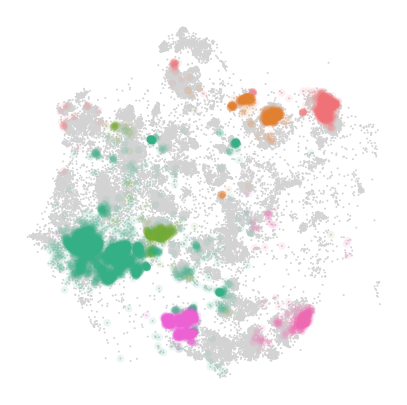

In [62]:
selected_clusters = np.array([2,
                              5,
                              16,
                              22,
                              45,
                              48])-1
df_clustered = df[df['mask_clustered'] == 1]


fig, ax = plt.subplots(1,1, figsize=(5,5))
ax.scatter(df_clustered['TRACE_0'].values,
           df_clustered['TRACE_1'].values, 
           facecolor='lightgray', 
           edgecolor='none', 
           rasterized=True, 
           s=2) 

# Plot example clusters
for idx_cluster in selected_clusters:
    df_cluster = df_clustered[df_clustered['response_type_ID'] == idx_cluster]
    
    ax.scatter(df_cluster['TRACE_0'].values, 
               df_cluster['TRACE_1'].values, 
               facecolor=cmap.colors[idx_cluster], 
               edgecolor='none',
               s=30,
               alpha=0.1,
               rasterized=True) 

ax.set_xticks([])
ax.set_yticks([])
sns.despine(bottom=True, left=True)
fig.patch.set_facecolor('white')

# Depths distribution across subtypes

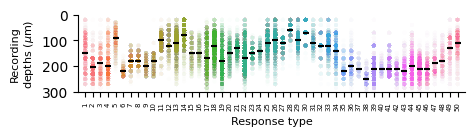

In [82]:
fig, ax = plt.subplots(1, 1, figsize=(5, 1))

df_clustered = df[df['mask_clustered'] == 1]

depths_median_cluster = []
for i in range(50):
    df_cluster = df_clustered[df_clustered['response_type_ID'] == i]
    depths_cluster = df_cluster['depth'].values
    depths_median_cluster.append(np.median(depths_cluster))

    ax.scatter(np.repeat(i, len(df_cluster)), 
               df_cluster['depth'], 
               s=10, 
               alpha=0.01, 
               edgecolor='none', 
               facecolor=cmap.colors[i], 
               rasterized=True)
    
    ax.scatter(i, 
               np.median(depths_cluster), 
               color='k', 
               marker='_', 
               s=15, 
               zorder=1, 
               rasterized=True)

ax.set_xticks(np.arange(0, 50, 1))
ax.set_xticklabels(np.arange(1, 51, 1), fontsize=5, rotation=90)
ax.set_xlim([-1, 50])
ax.set_ylim([np.max(df_clustered['depth'].values), 0])
ax.set_yticks([0,100,200,300])
ax.set_xlabel('Response type', fontsize=8)
ax.set_ylabel('Recording\ndepths ($\mu$m)', fontsize=8)
sns.despine()
fig.patch.set_facecolor('white')